In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_pickle('../data/processed/emails_with_anomalies.pkl')
style_df = pd.read_pickle('../data/features/stylistic_features.pkl')
print(f"Loaded {len(df):,} emails")

Loaded 458,386 emails


In [2]:
# Export anomaly scores for MATLAB
export = pd.DataFrame({
    'user': df['user'],
    'date': df['datetime'].astype(str),
    'anomaly_score': df['anomaly_score'],
    'anomaly_iso': df['anomaly_iso'],
    'anomaly_lof': df['anomaly_lof'],
    'strong_anomaly': df['strong_anomaly'],
    'dominant_topic': df['dominant_topic'],
    'avg_word_length': style_df['avg_word_length'],
    'vocab_richness': style_df['vocab_richness'],
    'num_words': style_df['num_words'],
})
export.to_csv('../results/anomaly_scores.csv', index=False)
print("Exported anomaly scores for MATLAB")

Exported anomaly scores for MATLAB


/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78670/2344028864.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df['datetime'].dt.to_period('M')).size()
/var/folders/f6/mm2rcp015fj73gp7jk4fbh4c0000gn/T/ipykernel_78670/2344028864.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_rate = df.groupby(df['datetime'].dt.to_period('M'))['strong_anomaly'].mean()


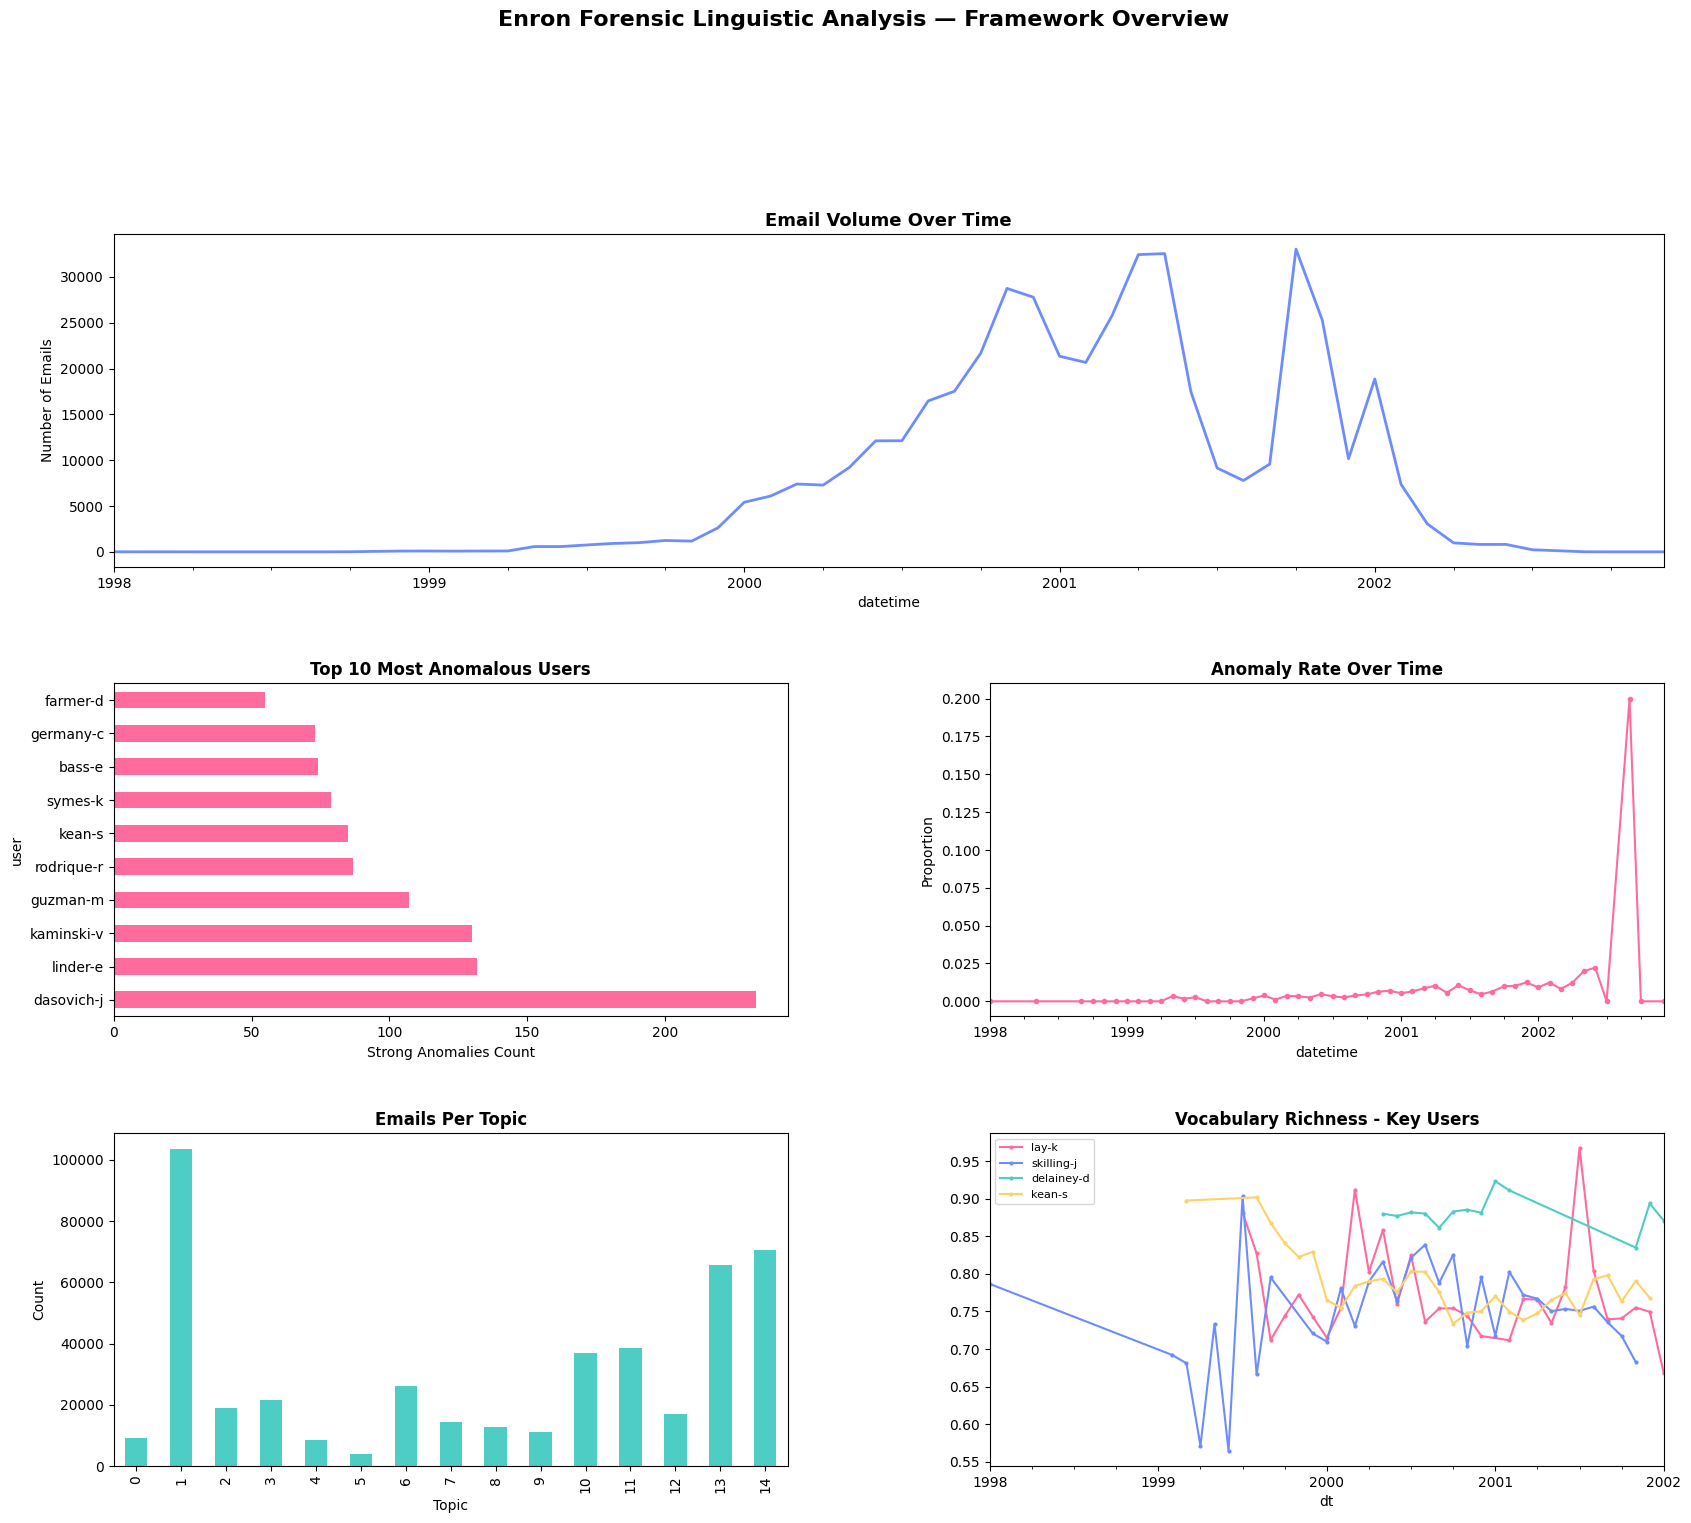

In [3]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# Panel 1: Email volume timeline
ax1 = fig.add_subplot(gs[0, :])
monthly = df.groupby(df['datetime'].dt.to_period('M')).size()
monthly.plot(ax=ax1, color='#6c8cff', linewidth=2)
ax1.set_title('Email Volume Over Time', fontweight='bold', fontsize=13)
ax1.set_ylabel('Number of Emails')
for date, event in {'2001-08': 'Skilling resigns', '2001-10': 'SEC investigation', '2001-12': 'Bankruptcy'}.items():
    try:
        ax1.axvline(x=monthly.index.get_loc(date), color='red', linestyle='--', alpha=0.7)
    except:
        pass

# Panel 2: Anomaly distribution by user
ax2 = fig.add_subplot(gs[1, 0])
anomaly_by_user = df[df['strong_anomaly']]['user'].value_counts().head(10)
anomaly_by_user.plot(kind='barh', ax=ax2, color='#ff6b9d')
ax2.set_title('Top 10 Most Anomalous Users', fontweight='bold')
ax2.set_xlabel('Strong Anomalies Count')

# Panel 3: Anomaly rate over time
ax3 = fig.add_subplot(gs[1, 1])
monthly_rate = df.groupby(df['datetime'].dt.to_period('M'))['strong_anomaly'].mean()
monthly_rate.plot(ax=ax3, color='#ff6b9d', marker='o', markersize=3)
ax3.set_title('Anomaly Rate Over Time', fontweight='bold')
ax3.set_ylabel('Proportion')

# Panel 4: Topic distribution
ax4 = fig.add_subplot(gs[2, 0])
df['dominant_topic'].value_counts().sort_index().plot(kind='bar', ax=ax4, color='#4ecdc4')
ax4.set_title('Emails Per Topic', fontweight='bold')
ax4.set_xlabel('Topic')
ax4.set_ylabel('Count')

# Panel 5: Writing style - key users vs average
ax5 = fig.add_subplot(gs[2, 1])
key_users = ['lay-k', 'skilling-j', 'delainey-d', 'kean-s']
colors = ['#ff6b9d', '#6c8cff', '#4ecdc4', '#ffd166']
for user, color in zip(key_users, colors):
    user_mask = df['user'] == user
    user_data = df[user_mask]
    monthly_wl = style_df[user_mask].assign(dt=user_data['datetime'].values).groupby(
        pd.to_datetime(style_df[user_mask].assign(dt=user_data['datetime'].values)['dt']).dt.to_period('M')
    )['vocab_richness'].mean()
    monthly_wl.plot(ax=ax5, color=color, marker='o', markersize=2, label=user)
ax5.set_title('Vocabulary Richness - Key Users', fontweight='bold')
ax5.legend(fontsize=8)

plt.suptitle('Enron Forensic Linguistic Analysis — Framework Overview',
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../results/figures/framework_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()

In [4]:
df.to_pickle('../data/processed/emails_with_anomalies.pkl')
print("All done - framework complete")

All done - framework complete
